# DS 5003, SP 2026 - Healthcare Data Science 

## *For Professor Christian Wernz, PhD, University of Virginia*

---

#### Team Members
* **Robert Ashby** | *University of Virginia, School of Data Science*  gsr3qz@virginia.edu
* **Xavier Colbert** | *University of Virginia, School of Data Science*  kxp3jj@virginia.edu
* **Alysa Pugmire** | *University of Virginia, School of Data Science*  amp3xs@virginia.edu
* **Jasmine Waller** | *University of Virginia, School of Data Science*  vwx5pn@virginia.edu

# CMS HAI Risk Prediction Pipeline
**Objective:** Develop a tool to determine if a facility is at risk of an HAI incident (HAI_1 through HAI_6) and identify which facility measures contribute most to correcting an "at-risk" status.

In [1]:
import sys
import numpy as np
import importlib
from pathlib import Path
import matplotlib.pyplot as plt

RANDOM_SEED = 42
# Set for numpy, pandas, and sklearn
np.random.seed(RANDOM_SEED)

# Add the 'code' folder to the system path so Python can find your scripts
if './code' not in sys.path:
    sys.path.append('./code')

print("Pipeline initialized. Ready to execute modules.")

Pipeline initialized. Ready to execute modules.


## 00: Data Retrieval

This step performs a self-healing raw-data check for the CMS hospital downloadable database.

The goal is to make the pipeline reproducible and portable. Rather than assuming the data already exists locally, the script checks whether a known CMS hospital CSV is present in the target raw-data folder. If the data is already available, the step is skipped. If not, the script downloads the current CMS hospital archive directly from the CMS Provider Data Catalog archive, extracts the contents into the project raw-data directory, and removes the zip file after extraction.

This design keeps the pipeline easier to run on a new machine and reduces manual setup errors.

In [2]:
step_00 = importlib.import_module("00_download_data")
importlib.reload(step_00)

download_success, raw_data_path = step_00.download_and_extract_cms_data()

print(f"Download success: {download_success}")
print(f"Resolved raw data path: {raw_data_path}")

[SKIP] CMS data already exists at: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\raw\cms_hospitals_jan2026
Download success: True
Resolved raw data path: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\raw\cms_hospitals_jan2026


## 01: Data Import

This step dynamically scans the CMS raw-data directory and imports every CSV file found in the extracted hospital archive.

The design choice here is to avoid hard-coding a small list of expected files. Instead, the script loads all available hospital-level, state-level, and national-level files into a dictionary of pandas DataFrames. This makes the pipeline more adaptable to future CMS archive updates, where files may be added, removed, or renamed between releases.

Column names are lightly standardized by stripping leading and trailing whitespace, but the original CMS naming conventions are otherwise preserved so that downstream steps remain interpretable against the CMS data dictionary.

In [3]:
# Import the module dynamically
step_01 = importlib.import_module("01_data_import")
importlib.reload(step_01)

# Execute the raw-data loading function
raw_datasets = step_01.load_all_raw_data()

print(f"\nTotal datasets loaded: {len(raw_datasets)}")

Scanning directory: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\raw\cms_hospitals_jan2026
--------------------------------------------------
Found 73 CSV files. Beginning import...

[LOADED] ASC_Facility                             | Rows: 5711    | Cols: 47
[LOADED] ASC_National                             | Rows: 1       | Cols: 37
[LOADED] ASC_State                                | Rows: 54      | Cols: 34
[LOADED] ASCQR_OAS_CAHPS_BY_ASC                   | Rows: 4452    | Cols: 30
[LOADED] ASCQR_OAS_CAHPS_NATIONAL                 | Rows: 1       | Cols: 21
[LOADED] ASCQR_OAS_CAHPS_STATE                    | Rows: 56      | Cols: 22
[LOADED] Birthing_Friendly_Hospitals_Geocoded     | Rows: 2265    | Cols: 7
[LOADED] CJR_Quality_Reporting_January_2026_Produ | Rows: 320     | Cols: 18
[LOADED] CMS_PSI_6_decimal_file                   | Rows: 52327   | Cols: 13
[LOADED] Complications_and_Deaths-Hospital        | Rows: 95780   | Cols: 18
[LOADED] Com

## 02: Data Interpretation

This step profiles all imported CMS datasets and creates a structured inventory report to support downstream dataset screening.

The purpose of this step is not modeling yet. Instead, it functions as a quality and usability audit of the available CMS files. For each dataset, the profile summarizes its size, memory footprint, the presence of facility identifiers, whether a `Measure ID` field exists, whether a likely value column exists, and whether the file appears suitable for hospital-level feature mining.

This gives the team a more systematic basis for deciding which datasets are likely to contribute useful predictors and which ones are primarily state-level, national-level, administrative, or otherwise low-value for the modeling objective.

In [4]:
step_02 = importlib.import_module("02_data_interpretation")
importlib.reload(step_02)

# Generate the dataset profile report
if raw_datasets:
    data_profile = step_02.generate_data_profile(raw_datasets)
    display(data_profile.head(15))
else:
    print("No data available to profile.")


Analyzing datasets...

[SUCCESS] Data interpretation profile saved to: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\interim\dataset_inventory_profile.csv
[INFO] Review this CSV to identify facility-level hospital files,
       likely feature sources, and low-value summary datasets.


,Dataset_Name,Row_Count,Column_Count,Has_Facility_ID,Facility_ID_Column,Unique_Facility_IDs,Has_Measure_ID,Measure_ID_Column,Likely_Value_Column,Potential_Hospital_File,Memory_MB,Columns_List
0,Healthcare_Associated_Infections-Hospital,172404,15,True,Facility ID,4789.0,True,Measure ID,Score,True,145.91,"Facility ID, Facility Name, Address, City/Town..."
1,Timely_and_Effective_Care-Hospital,138129,16,True,Facility ID,4657.0,True,Measure ID,Score,True,126.30,"Facility ID, Facility Name, Address, City/Town..."
2,Complications_and_Deaths-Hospital,95780,18,True,Facility ID,4789.0,True,Measure ID,Score,True,95.69,"Facility ID, Facility Name, Address, City/Town..."
3,Unplanned_Hospital_Visits-Hospital,67046,20,True,Facility ID,4789.0,True,Measure ID,Score,True,75.94,"Facility ID, Facility Name, Address, City/Town..."
4,Outpatient_Imaging_Efficiency-Hospital,18500,14,True,Facility ID,4625.0,True,Measure ID,Score,True,13.33,"Facility ID, Facility Name, Address, City/Town..."
5,Maternal_Health-Hospital,17968,15,True,Facility ID,4657.0,True,Measure ID,Score,True,14.40,"Facility ID, Facility Name, Address, City/Town..."
6,Medicare_Hospital_Spending_Per_Patient-Hospital,4625,14,True,Facility ID,4625.0,True,Measure ID,Score,True,3.31,"Facility ID, Facility Name, Address, City/Town..."
7,PATIENT_REPORTED_OUTCOMES_FACILITY,4625,15,True,Facility ID,4625.0,True,Measure ID,Score,True,3.76,"Facility ID, Facility Name, Address, City/Town..."
8,HOSPITAL_QUARTERLY_MSPB_6_DECIMALS,2974,6,True,Facility ID,2974.0,True,Measure ID,Value,True,0.56,"Facility ID, Measure ID, Value, Footnote, Star..."
9,VA_TE,1452,17,True,Facility ID,132.0,True,Measure ID,Score,True,1.37,"Facility ID, Facility Name, Address, City/Town..."


## 03: Data-Driven Ground Truth Construction

The predictive target is based on the CMS Standardized Infection Ratio (SIR), which is a risk-adjusted measure comparing a facility’s observed infection burden to a benchmarked expected value. In the CMS hospital HAI files, a value greater than 1.0 indicates worse-than-benchmark performance on that infection measure.

The primary binary outcome for this project is `HAI_at_risk`. A facility is assigned `HAI_at_risk = 1` if any reported HAI SIR measure exceeds 1.0. This treats elevated HAI risk as a facility-level vulnerability rather than as a single isolated infection event.

To preserve the interpretability of the target construction step, the pipeline now saves two outputs:

1. A detailed facility-level HAI target file containing counts of reported HAI SIR measures, counts of worse-than-benchmark measures, and facility-level HAI subtype indicators.
2. A master modeling file containing the primary binary target merged with a small set of structural hospital descriptors from the CMS general hospital information file.

This preserves the original modeling target while creating richer target metadata for later interpretation and reporting.

In [5]:
step_03 = importlib.import_module("03_data_processing")
importlib.reload(step_03)

if "raw_datasets" in locals():
    master_data = step_03.build_target_and_master(raw_datasets)
    display(master_data.head())
else:
    print("raw_datasets not found. Run Step 01 first.")

--- 03 Processing Complete ---
Total Facilities in target detail file: 4789
Total Facilities in master modeling file: 4789
At Risk Count: 1432
[SUCCESS] Saved target detail file to: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\processed\facility_hai_target_detail.csv
[SUCCESS] Saved master modeling file to: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\processed\master_model_data.csv


,Facility ID,HAI_at_risk,Hospital Type,Hospital Ownership,Hospital overall rating
0,010001,0,Acute Care Hospitals,Government - Hospital District or Authority,4
1,010005,1,Acute Care Hospitals,Government - Hospital District or Authority,3
2,010006,0,Acute Care Hospitals,Proprietary,2
3,010007,0,Acute Care Hospitals,Voluntary non-profit - Private,1
4,010008,0,Acute Care Hospitals,Proprietary,Not Available


## 04: Exploratory Data Analysis

Before moving into feature mining and model fitting, this step summarizes the facility population represented in the master modeling file.

The goal of this stage is to provide a compact descriptive view of the dataset rather than an exhaustive exploratory analysis. In particular, the step examines:

1. the overall distribution of the binary HAI risk target,
2. differences in at-risk rates across hospital types,
3. differences in at-risk rates across hospital ownership categories, and
4. missingness patterns in the small set of structural variables retained from the CMS general hospital information file.

These outputs serve two purposes. First, they help verify that the target construction step produced a plausible population for modeling. Second, they provide context for interpreting later model results, especially when structural or organizational features appear to be associated with HAI risk.

[SUCCESS] Saved class distribution table to: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\processed\eda_class_distribution.csv


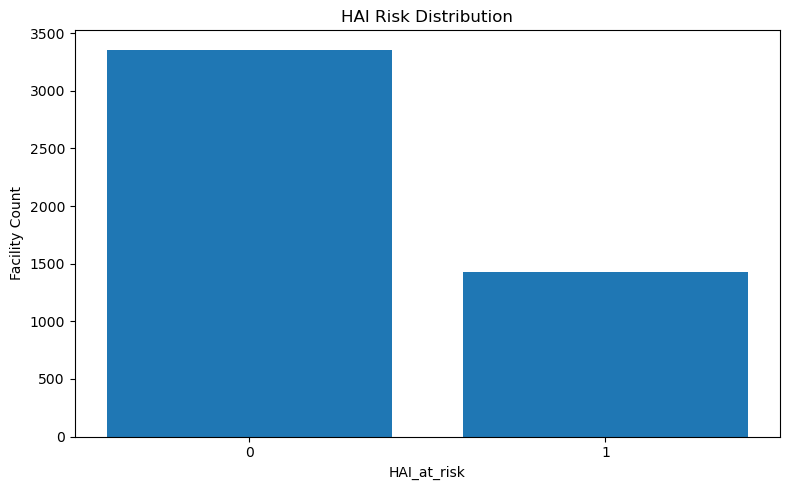

[SUCCESS] Saved figure to: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\reports\figures\eda_hai_risk_distribution.png
[SUCCESS] Saved hospital type summary table to: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\processed\eda_hospital_type_summary.csv


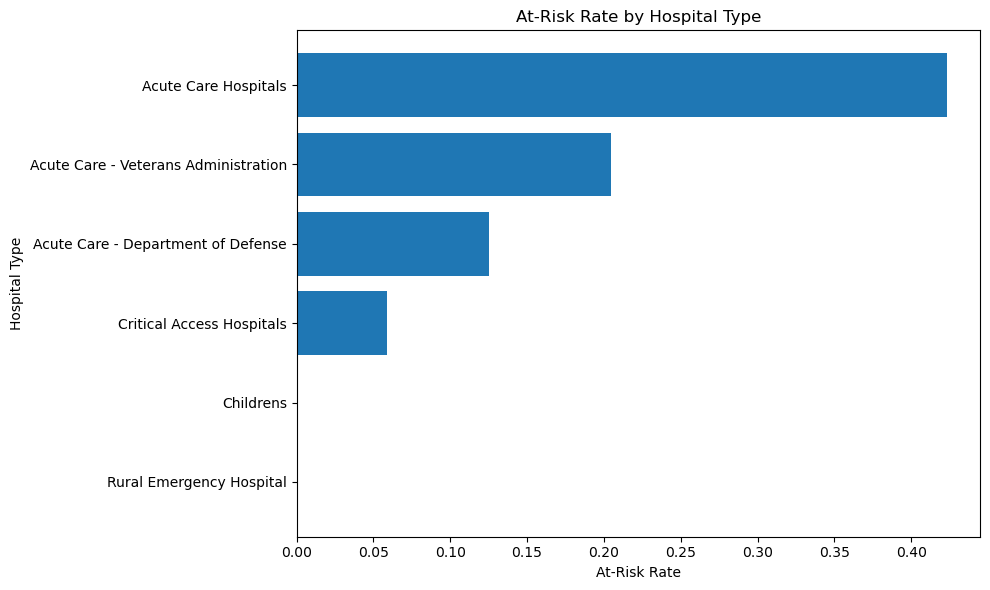

[SUCCESS] Saved figure to: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\reports\figures\eda_at_risk_rate_by_hospital_type.png
[SUCCESS] Saved hospital ownership summary table to: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\processed\eda_hospital_ownership_summary.csv


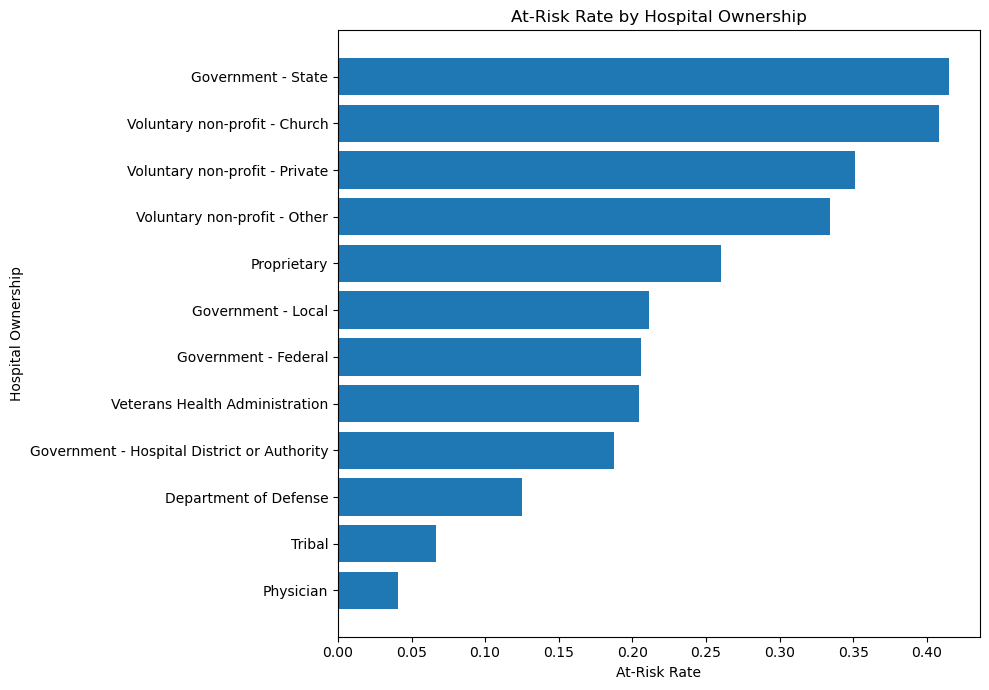

[SUCCESS] Saved figure to: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\reports\figures\eda_at_risk_rate_by_hospital_ownership.png
[SUCCESS] Saved structural missingness summary table to: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\processed\eda_structural_missingness_summary.csv
[SUCCESS] Step 04 EDA complete.


In [6]:
step_04 = importlib.import_module("04_data_analysis")
importlib.reload(step_04)

if "master_data" in locals():
    eda_outputs = step_04.run_eda()
else:
    print("master_data not found. Run Step 03 first.")

## 05: Dynamic Feature Discovery and Selection

This step expands the master modeling dataset by mining additional facility-level predictor variables from eligible CMS hospital files.

The process begins with the facility cohort created in Step 03. That master file provides the modeling anchor, meaning that all candidate predictors must map back to a facility with a known `HAI_at_risk` label.

The feature discovery logic is intentionally selective rather than exhaustive. A dataset is only used if it satisfies several criteria:

1. it is not part of an explicitly excluded source list,
2. it contains a `Facility ID` field,
3. it contains a `Measure ID` field,
4. it contains a usable numeric value column such as `Score` or `Value`, and
5. it covers at least a minimum proportion of the target hospital cohort.

For eligible files, the CMS long-format measure structure is converted into a wide modeling format by pivoting `Measure ID` values into feature columns. After pivoting, individual columns are filtered by completion threshold so that extremely sparse predictors are removed before modeling.

A key methodological improvement in this version of the pipeline is that missing numeric values are preserved at this stage rather than imputed immediately. Final imputation is deferred to the model preprocessing pipelines so that missing-value handling occurs inside the train/test modeling workflow rather than during early feature assembly.

In addition to the final merged feature set, this step now saves a feature manifest that records the source dataset, value column used, overlap statistics, and completion rate for each retained feature. This supports later pruning, interpretation, and report writing.

In [7]:
step_05 = importlib.import_module("05_feature_identification")
importlib.reload(step_05)

if "raw_datasets" in locals():
    final_df = step_05.mine_features(
        raw_datasets,
        exclude_files=["Healthcare_Associated_Infections-Hospital"]
    )
    display(final_df.head())
else:
    print("raw_datasets not found. Run Step 01 first.")

Targeting predictors for 4789 facilities...
[DATA DISCOVERED] Complications_and_Deaths-Hospital: Added 15 features.
[SKIP - EXCLUDED SOURCE] Healthcare_Associated_Infections-Hospital
[DATA DISCOVERED] HOSPITAL_QUARTERLY_MSPB_6_DECIMALS: Added 1 features.
[DATA DISCOVERED] Medicare_Hospital_Spending_Per_Patient-Hospital: Added 1 features.
[DATA DISCOVERED] Outpatient_Imaging_Efficiency-Hospital: Added 2 features.
[DATA DISCOVERED] Timely_and_Effective_Care-Hospital: Added 11 features.
[DATA DISCOVERED] Unplanned_Hospital_Visits-Hospital: Added 8 features.
------------------------------
[SUCCESS] Final Feature Set Shape: (4789, 43)
[INFO] Included feature sources: ['Complications_and_Deaths-Hospital', 'HOSPITAL_QUARTERLY_MSPB_6_DECIMALS', 'Medicare_Hospital_Spending_Per_Patient-Hospital', 'Outpatient_Imaging_Efficiency-Hospital', 'Timely_and_Effective_Care-Hospital', 'Unplanned_Hospital_Visits-Hospital']
[INFO] Excluded feature sources: ['Healthcare_Associated_Infections-Hospital']
[SUCC

,Facility ID,HAI_at_risk,Hospital Type,Hospital Ownership,Hospital overall rating,Hybrid_HWM,MORT_30_COPD,MORT_30_HF,MORT_30_PN,PSI_03,...,SEV_SEP_3HR,SEV_SEP_6HR,EDAC_30_HF,EDAC_30_PN,Hybrid_HWR,OP_32,OP_36,READM_30_COPD,READM_30_HF,READM_30_PN
0,010001,0,Acute Care Hospitals,Government - Hospital District or Authority,4,4.5,9.4,10.2,18.4,0.13,...,78.0,97.0,-1.1,17.4,15.1,12.7,1.1,18.0,20.1,16.0
1,010005,1,Acute Care Hospitals,Government - Hospital District or Authority,3,4.6,8.9,14.1,21.2,0.33,...,85.0,99.0,12.2,-17.2,13.3,13.0,0.9,17.1,19.8,13.9
2,010006,0,Acute Care Hospitals,Proprietary,2,5.2,8.7,12.5,19.6,0.55,...,78.0,96.0,-4.7,-0.9,15.9,11.1,1.2,19.1,19.5,15.7
3,010007,0,Acute Care Hospitals,Voluntary non-profit - Private,1,4.8,11.2,13.4,25.4,0.54,...,62.0,NaN,77.9,29.8,15.4,12.5,NaN,18.6,20.9,16.5
4,010008,0,Acute Care Hospitals,Proprietary,Not Available,4.3,NaN,NaN,15.0,0.60,...,NaN,NaN,NaN,-8.9,14.7,12.7,NaN,NaN,NaN,16.0


## Cross-Validation Sanity Check

Before defining the final held-out modeling workflow, this checkpoint verifies that stratified splitting preserves the at-risk class balance across folds. Although the final model comparison will use a held-out train/test split with inner cross-validation for tuning, this intermediate check is still useful for confirming that the binary target remains stable under repeated stratified partitioning.

This section is utilized as an early validation step in the project workflow because it provides a quick diagnostic on class balance before moving into full model training.

In [8]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold

# Setup a stratified 5-fold split to verify class balance stability
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# Separate features and target
X = final_df.drop("HAI_at_risk", axis=1)
y = final_df["HAI_at_risk"]

fold_results = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]

    train_ratio = y_train_fold.mean()
    test_ratio = y_test_fold.mean()

    fold_results.append({
        "fold": fold,
        "train_size": len(X_train_fold),
        "test_size": len(X_test_fold),
        "train_at_risk_rate": train_ratio,
        "test_at_risk_rate": test_ratio,
    })

    print(f"--- Fold {fold} ---")
    print(f"Train At-Risk Ratio: {train_ratio:.2%}")
    print(f"Test At-Risk Ratio:  {test_ratio:.2%}")
    print(f"Train size: {len(X_train_fold)}, Test size: {len(X_test_fold)}")

fold_check_df = pd.DataFrame(fold_results)
display(fold_check_df)

--- Fold 1 ---
Train At-Risk Ratio: 29.91%
Test At-Risk Ratio:  29.85%
Train size: 3831, Test size: 958
--- Fold 2 ---
Train At-Risk Ratio: 29.91%
Test At-Risk Ratio:  29.85%
Train size: 3831, Test size: 958
--- Fold 3 ---
Train At-Risk Ratio: 29.89%
Test At-Risk Ratio:  29.96%
Train size: 3831, Test size: 958
--- Fold 4 ---
Train At-Risk Ratio: 29.89%
Test At-Risk Ratio:  29.96%
Train size: 3831, Test size: 958
--- Fold 5 ---
Train At-Risk Ratio: 29.91%
Test At-Risk Ratio:  29.89%
Train size: 3832, Test size: 957


,fold,train_size,test_size,train_at_risk_rate,test_at_risk_rate
0,1,3831,958,0.299139,0.298539
1,2,3831,958,0.299139,0.298539
2,3,3831,958,0.298878,0.299582
3,4,3831,958,0.298878,0.299582
4,5,3832,957,0.299061,0.298851


## 05b: Feature Governance and Pruning

At this stage, the pipeline has assembled a broad candidate feature set from multiple CMS hospital files. However, not all retained variables should automatically enter the final modeling workflow unchanged.

This step introduces a more formal feature-governance process between broad feature mining and model training. The goal is to make the modeling dataset more defensible, more interpretable, and more aligned with the project’s intended hospital leadership use case.

The pruning workflow applied here has two layers:

1. **Methodological exclusions**  
   Certain variables are removed by design rather than by pure predictive performance. These include identifiers and structural context variables that are either not actionable, not appropriate for a facility-improvement framing, or too closely tied to broad organizational characteristics rather than operational quality processes.

2. **Correlation-based redundancy pruning**  
   Among the remaining numeric predictors, highly correlated variables are screened using an absolute correlation threshold. This reduces redundancy in the predictor space and helps stabilize later interpretation, especially for models such as logistic regression where strongly collinear predictors can produce unstable or counterintuitive coefficient patterns.

This step does not yet perform embedded or model-based feature selection. Instead, it provides a transparent and lightweight first pruning stage that preserves the existing project architecture while improving methodological rigor.

In [9]:
step_05b = importlib.import_module("05b_feature_pruning")
importlib.reload(step_05b)

pruning_results = step_05b.prune_features(
    input_csv="../data/processed/final_modeling_feature_set.csv",
    manual_drop_cols=[
        "Facility ID",
        "Hospital overall rating",
        "Hospital Type",
        "Hospital Ownership",
    ],
    correlation_threshold=0.85,
    run_correlation_pruning=True,
)

# first-pass threshold at .85 
# If later found that it doesnt drop enough, or perhaps too much, 
# we can adjust the threshold and re-run this cell to see
# the impact on the pruned dataset and correlation details.

pruned_df = pruning_results["pruned_df"]
display(pruning_results["pruning_summary_df"])
display(pruning_results["correlation_detail_df"].head(20))
print(f"Pruned dataset shape: {pruned_df.shape}")

[SUCCESS] Feature governance and pruning complete.
[INFO] Original feature count: 42
[INFO] Manual drop count: 4
[INFO] Correlation drop count: 3
[INFO] Final feature count: 35
[SUCCESS] Saved pruned feature set to: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\processed\pruned_modeling_feature_set.csv
[SUCCESS] Saved pruning summary to: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\processed\feature_pruning_summary.csv
[SUCCESS] Saved retained features to: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\processed\retained_model_features.csv


,original_feature_count,manual_drop_count,correlation_drop_count,final_feature_count,correlation_threshold
0,42,4,3,35,0.85


,feature_kept,feature_dropped,abs_correlation
0,MSPB-1_x,MSPB-1_y,0.999477
1,OP_18a,OP_18b,0.991169
2,SEP_1,SEV_SEP_3HR,0.852505


Pruned dataset shape: (4789, 36)


## Modeling Setup

The next stage builds a consistent modeling workflow across Logistic Regression, Random Forest, and XGBoost using the pruned feature set produced in Step 05b.

A held-out test split is created for final model comparison, while stratified 5-fold cross-validation is retained inside the training data for hyperparameter tuning. This preserves a clear separation between model selection and final evaluation.

Separate preprocessing pipelines are defined for linear and tree-based models. For the linear model, numeric variables are both imputed and standardized. For the tree-based models, numeric variables are imputed but not scaled. Categorical variables, if present after pruning, are imputed and one-hot encoded.

This setup ensures that missing-value handling occurs inside the modeling workflow rather than during early feature assembly, which keeps the pipeline methodologically cleaner and more reproducible.

In [10]:
# Modeling imports
import importlib
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ------------------------------------------------------------
# Train/test split for final held-out evaluation
# ------------------------------------------------------------
X = pruned_df.drop(columns=["HAI_at_risk"])
y = pruned_df["HAI_at_risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_SEED
)

print(f"Training rows: {X_train.shape[0]}")
print(f"Test rows: {X_test.shape[0]}")
print(f"Train at-risk rate: {y_train.mean():.2%}")
print(f"Test at-risk rate: {y_test.mean():.2%}")

# ------------------------------------------------------------
# Inner CV used for model tuning on the training set only
# ------------------------------------------------------------
cv_inner = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_SEED
)

# ------------------------------------------------------------
# Identify column types
# ------------------------------------------------------------
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

# ------------------------------------------------------------
# Preprocessing for Logistic Regression
# ------------------------------------------------------------
numeric_transformer_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_logreg = ColumnTransformer([
    ("num", numeric_transformer_scaled, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# ------------------------------------------------------------
# Preprocessing for Random Forest and XGBoost
# ------------------------------------------------------------
numeric_transformer_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocess_tree = ColumnTransformer([
    ("num", numeric_transformer_tree, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# ------------------------------------------------------------
# Class-balance settings
# ------------------------------------------------------------
class_weight_balanced = "balanced"
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"scale_pos_weight: {scale_pos_weight:.3f}")

Training rows: 3831
Test rows: 958
Train at-risk rate: 29.91%
Test at-risk rate: 29.85%
Numeric features: 35
Categorical features: 0
scale_pos_weight: 2.343


## 06: Logistic Regression

Logistic Regression serves as the most interpretable baseline in the modeling suite.

Because it is a linear model, the preprocessing pipeline includes both median imputation for missing numeric values and standardization of numeric predictors. This is especially important now that missing values are intentionally preserved during feature assembly and handled inside the modeling workflow instead.

An elastic net specification is used as the default configuration because it provides a compromise between pure L1 and pure L2 regularization. In practice, this helps control coefficient instability when predictors remain somewhat correlated, while still allowing the model to shrink weaker predictors toward zero.

Hyperparameters are tuned using stratified 5-fold cross-validation on the training set only, and final held-out evaluation is deferred until Step 09.

In [11]:
# Step 06: Logistic Regression
step_06 = importlib.import_module("06_model_logreg")
importlib.reload(step_06)

logreg_cv, logreg_pipe, logreg_params = step_06.run_logreg_model(
    preprocess=preprocess_logreg,
    cv=cv_inner,
    Xtrain=X_train,
    ytrain=y_train,
    penalty="elasticnet",
    class_weight=class_weight_balanced,
    random_seed=RANDOM_SEED,
    n_iter=25,
    scoring="roc_auc",
    n_jobs=-1
)

logreg_best = logreg_cv.best_estimator_

print("Best Logistic Regression CV ROC-AUC:", round(logreg_cv.best_score_, 4))
print("Best Logistic Regression Params:")
print(logreg_cv.best_params_)

logreg_results = pd.DataFrame(logreg_cv.cv_results_)
logreg_summary_cols = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "param_logreg__C",
]

if "param_logreg__l1_ratio" in logreg_results.columns:
    logreg_summary_cols.append("param_logreg__l1_ratio")

display(
    logreg_results[logreg_summary_cols]
    .sort_values("rank_test_score")
    .head(10)
)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


c:\Users\rjaxb\miniconda3\envs\cms-hai-risk-prediction\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Best Logistic Regression CV ROC-AUC: 0.7897
Best Logistic Regression Params:
{'logreg__C': np.float64(5309.5322690092235), 'logreg__l1_ratio': np.float64(0.1111111111111111)}


,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_logreg__C,param_logreg__l1_ratio
18,1,0.789701,0.014302,0.803905,5309.532269,0.111111
15,2,0.789696,0.014311,0.803904,757.745305,0.666667
7,3,0.789683,0.014323,0.803904,456.605487,0.555556
5,4,0.789680,0.014339,0.803871,46.193474,0.555556
9,5,0.789620,0.014344,0.803838,8.706670,1.000000
22,6,0.789545,0.014432,0.803750,7.585309,0.777778
1,7,0.789308,0.014661,0.803643,6.155564,0.666667
14,8,0.789023,0.015033,0.803371,5.486767,0.222222
10,9,0.788723,0.015344,0.803196,1.577798,0.888889
2,10,0.783561,0.016326,0.797710,0.368691,0.666667


## 07: Random Forest

Random Forest provides a nonlinear ensemble baseline that can capture interactions, threshold effects, and more flexible decision boundaries than Logistic Regression.

Because tree-based models do not require standardized numeric inputs, the preprocessing pipeline used here applies imputation but does not apply scaling to numeric predictors. Categorical variables, if present after pruning, are still imputed and one-hot encoded so that the feature space remains compatible with the sklearn pipeline framework.

Hyperparameters are tuned using stratified 5-fold cross-validation on the training set only. This allows the project to compare a more flexible nonlinear model against the linear logistic baseline while preserving the same held-out evaluation structure for final comparison.

In [12]:
# Step 07: Random Forest
step_07 = importlib.import_module("07_model_randforest")
importlib.reload(step_07)

rf_cv, rf_pipe, rf_params = step_07.run_rf_model(
    preprocess=preprocess_tree,
    cv=cv_inner,
    Xtrain=X_train,
    ytrain=y_train,
    class_weight=class_weight_balanced,
    random_seed=RANDOM_SEED,
    n_iter=25,
    scoring="roc_auc",
    n_jobs=-1
)

rf_best = rf_cv.best_estimator_

print("Best Random Forest CV ROC-AUC:", round(rf_cv.best_score_, 4))
print("Best Random Forest Params:")
print(rf_cv.best_params_)

rf_results = pd.DataFrame(rf_cv.cv_results_)
rf_summary_cols = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "param_rf__n_estimators",
    "param_rf__max_depth",
    "param_rf__min_samples_split",
    "param_rf__min_samples_leaf",
    "param_rf__max_features",
]

display(
    rf_results[rf_summary_cols]
    .sort_values("rank_test_score")
    .head(10)
)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Random Forest CV ROC-AUC: 0.8387
Best Random Forest Params:
{'rf__max_depth': 20, 'rf__max_features': 'log2', 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 10, 'rf__n_estimators': 289}


,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_rf__n_estimators,param_rf__max_depth,param_rf__min_samples_split,param_rf__min_samples_leaf,param_rf__max_features
14,1,0.838686,0.008532,0.986189,289,20,10,4,log2
23,2,0.838217,0.007923,0.988508,313,30,9,4,sqrt
15,3,0.838071,0.007179,0.982652,466,30,3,5,log2
5,4,0.837691,0.007229,0.982058,148,20,10,5,log2
17,5,0.837409,0.006920,0.982003,256,20,10,5,log2
10,6,0.837114,0.007505,0.989988,363,30,8,4,log2
2,7,0.837025,0.008203,0.965499,459,10,5,5,sqrt
3,8,0.837023,0.008246,0.965474,443,10,3,5,log2
16,9,0.836616,0.009011,0.994969,351,30,10,2,log2
9,10,0.836607,0.008828,0.993570,445,20,10,2,log2


## 08: XGBoost

XGBoost serves as the gradient-boosted tree baseline in the modeling workflow.

Like Random Forest, it can capture nonlinear relationships and interactions among predictors without requiring standardized numeric inputs. However, because it fits boosted decision trees sequentially, it can often achieve stronger predictive performance than a single bagged tree ensemble when the signal structure is complex.

The positive-class weight is scaled using the class distribution of the training data so that the model places greater emphasis on the minority at-risk class during fitting. Hyperparameters are tuned using stratified 5-fold cross-validation on the training set only, preserving the same held-out evaluation framework used for the other models.

In [13]:
# Step 08: XGBoost
step_08 = importlib.import_module("08_model_xgboost")
importlib.reload(step_08)

xgb_cv, xgb_pipe, xgb_params = step_08.run_xgb_model(
    preprocess=preprocess_tree,
    cv=cv_inner,
    Xtrain=X_train,
    ytrain=y_train,
    scale_pos_weight=scale_pos_weight,
    random_seed=RANDOM_SEED,
    n_iter=25,
    scoring="roc_auc",
    n_jobs=-1 # avoiding thread oversubscription and making runs slower or noisier
)

xgb_best = xgb_cv.best_estimator_

print("Best XGBoost CV ROC-AUC:", round(xgb_cv.best_score_, 4))
print("Best XGBoost Params:")
print(xgb_cv.best_params_)

xgb_results = pd.DataFrame(xgb_cv.cv_results_)
xgb_summary_cols = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "param_xgb__n_estimators",
    "param_xgb__learning_rate",
    "param_xgb__max_depth",
    "param_xgb__min_child_weight",
    "param_xgb__subsample",
    "param_xgb__colsample_bytree",
]

display(
    xgb_results[xgb_summary_cols]
    .sort_values("rank_test_score")
    .head(10)
)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best XGBoost CV ROC-AUC: 0.8371
Best XGBoost Params:
{'xgb__colsample_bytree': np.float64(0.8), 'xgb__learning_rate': np.float64(0.014049959523783904), 'xgb__max_depth': 5, 'xgb__min_child_weight': 5, 'xgb__n_estimators': 199, 'xgb__subsample': np.float64(0.8)}


,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_xgb__n_estimators,param_xgb__learning_rate,param_xgb__max_depth,param_xgb__min_child_weight,param_xgb__subsample,param_xgb__colsample_bytree
1,1,0.837109,0.007041,0.938742,199,0.014050,5,5,0.8,0.8
6,2,0.836151,0.009124,0.980770,415,0.012476,6,1,0.7,0.6
14,3,0.836075,0.010266,0.879006,235,0.010546,3,1,0.8,0.6
24,4,0.833427,0.008142,0.975601,227,0.021021,6,3,0.7,0.9
8,5,0.833400,0.010723,0.982233,305,0.015145,7,3,0.6,0.9
17,6,0.832559,0.008652,0.995371,198,0.030816,9,5,0.9,0.9
13,7,0.832423,0.012614,0.908029,114,0.063333,3,5,1.0,0.9
10,8,0.831018,0.009852,0.998072,317,0.018752,9,2,0.9,0.9
20,9,0.830698,0.010771,0.970619,151,0.044561,5,1,1.0,0.7
9,10,0.828307,0.009400,0.993261,489,0.018586,6,2,0.7,0.9


## 09: Held-Out Model Evaluation and Interpretation

This step compares the tuned models on the same held-out test set and summarizes their performance using metrics that are more informative than accuracy alone for an imbalanced healthcare risk-screening problem.

The evaluation outputs include:
- ROC-AUC and average precision,
- balanced accuracy,
- precision, recall, F1, and Matthews Correlation Coefficient,
- confusion matrices,
- threshold sweeps for operating-point selection,
- ROC and precision-recall curves, and
- feature-importance summaries for model interpretation.

A key goal of this stage is not only to identify the strongest predictive model, but also to interpret the result in a way that is useful for hospital leadership. For that reason, the evaluator now supports plain-language relabeling of CMS-style feature names and can also compute permutation importance on held-out data as a more robust interpretation check for fitted models.

In [14]:
step_09 = importlib.import_module("09_evaluator")
importlib.reload(step_09)

<module '09_evaluator' from 'd:\\Documents\\School\\UVA\\MSDS\\DS 5003\\Project\\GitHub\\cms-hai-risk-prediction\\code\\09_evaluator.py'>

In [15]:
models = {
    "Logistic Regression": logreg_best,
    "Random Forest": rf_best,
    "XGBoost": xgb_best
}

results_df = step_09.compare_models(
    models=models,
    X_eval=X_test,
    y_eval=y_test,
    threshold=0.50,
    save_csv=True
)

display(results_df)


===== Logistic Regression =====
Threshold: 0.50
Confusion Matrix:
[[484 188]
 [ 78 208]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.72      0.78       672
           1       0.53      0.73      0.61       286

    accuracy                           0.72       958
   macro avg       0.69      0.72      0.70       958
weighted avg       0.76      0.72      0.73       958


===== Random Forest =====
Threshold: 0.50
Confusion Matrix:
[[530 142]
 [ 61 225]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.79      0.84       672
           1       0.61      0.79      0.69       286

    accuracy                           0.79       958
   macro avg       0.75      0.79      0.76       958
weighted avg       0.81      0.79      0.79       958


===== XGBoost =====
Threshold: 0.50
Confusion Matrix:
[[502 170]
 [ 52 234]]

Classification Report:
              precisio

,model,threshold,roc_auc,avg_precision,balanced_accuracy,precision,recall,f1,mcc,tn,fp,fn,tp
0,Random Forest,0.5,0.851581,0.656275,0.787702,0.613079,0.786713,0.689127,0.541644,530,142,61,225
1,XGBoost,0.5,0.849749,0.656571,0.782603,0.579208,0.818182,0.678261,0.523755,502,170,52,234
2,Logistic Regression,0.5,0.795605,0.588439,0.723755,0.525253,0.727273,0.609971,0.415868,484,188,78,208


In [16]:
rf_eval = step_09.evaluate_classifier(
    model=rf_best,
    X_eval=X_test,
    y_eval=y_test,
    model_name="Random Forest",
    threshold=0.50,
    save_confusion_plot=True,
    normalize_confusion="true"
)


===== Random Forest =====
Threshold: 0.50
Confusion Matrix:
[[530 142]
 [ 61 225]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.79      0.84       672
           1       0.61      0.79      0.69       286

    accuracy                           0.79       958
   macro avg       0.75      0.79      0.76       958
weighted avg       0.81      0.79      0.79       958



## Confusion Matrix Visualization

To make the held-out classification results easier to interpret, the confusion matrix is visualized in two complementary ways:

1. **Raw counts**, which show the absolute number of facilities classified into each outcome category.
2. **Row-normalized percentages**, which show the proportion of each true class assigned to each predicted class.

The count version is useful for understanding the magnitude of false positives and false negatives. The normalized version is useful for comparing classification performance across classes when the dataset is imbalanced.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_pretty_confusion_matrix(
    model,
    X_eval,
    y_eval,
    model_name,
    threshold=0.50,
    labels=("Not At Risk", "At Risk"),
    normalize="true",
    figsize=(7, 6),
):
    y_prob = model.predict_proba(X_eval)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    cm_counts = confusion_matrix(y_eval, y_pred)
    cm_norm = confusion_matrix(y_eval, y_pred, normalize=normalize)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm_norm, interpolation="nearest", cmap="Blues")
    cbar = fig.colorbar(im, ax=ax)
    cbar.ax.set_ylabel("Row Proportion", rotation=270, labelpad=15)

    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        xlabel="Predicted Label",
        ylabel="True Label",
        title=f"{model_name} Held-Out Confusion Matrix (Threshold = {threshold:.2f})"
    )

    threshold_text = cm_norm.max() / 2.0

    for i in range(cm_counts.shape[0]):
        for j in range(cm_counts.shape[1]):
            cell_text = f"{cm_counts[i, j]}\n({cm_norm[i, j]:.1%})"
            ax.text(
                j,
                i,
                cell_text,
                ha="center",
                va="center",
                color="white" if cm_norm[i, j] > threshold_text else "black",
                fontsize=12,
                fontweight="bold"
            )

    plt.tight_layout()
    plt.show()

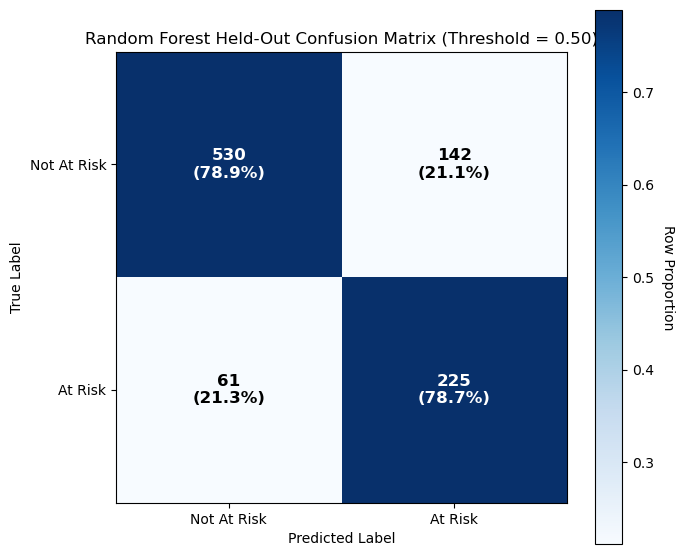

In [18]:
plot_pretty_confusion_matrix(
    model=rf_best,
    X_eval=X_test,
    y_eval=y_test,
    model_name="Random Forest",
    threshold=0.50
)

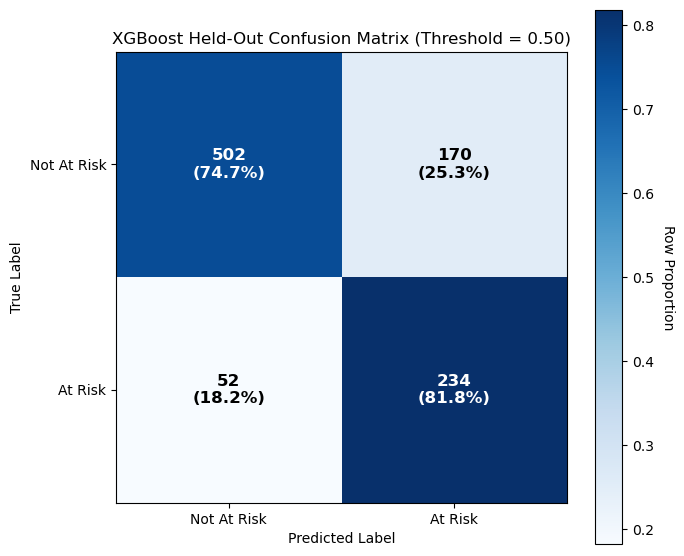

In [19]:
plot_pretty_confusion_matrix(
    model=xgb_best,
    X_eval=X_test,
    y_eval=y_test,
    model_name="XGBoost",
    threshold=0.50
)

The confusion matrix shows balanced performance across both classes, with approximately 79% of “At Risk” and “Not At Risk” facilities correctly identified. This indicates the model is not biased toward the majority class despite class imbalance.

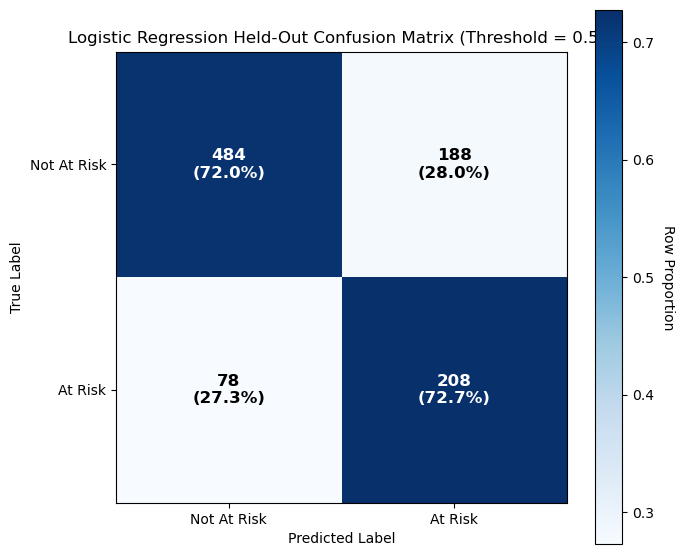

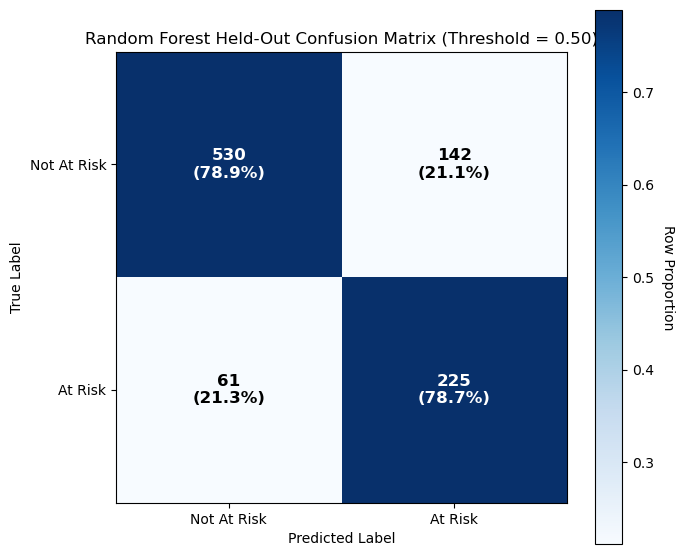

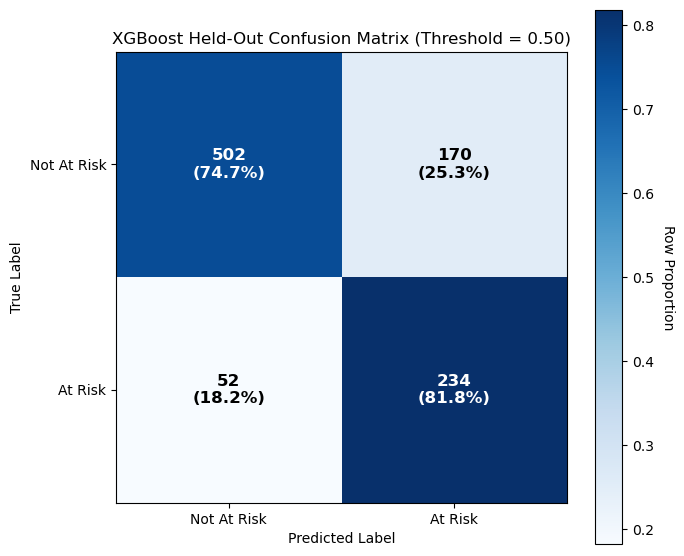

In [20]:
plot_pretty_confusion_matrix(logreg_best, X_test, y_test, "Logistic Regression")
plot_pretty_confusion_matrix(rf_best, X_test, y_test, "Random Forest")
plot_pretty_confusion_matrix(xgb_best, X_test, y_test, "XGBoost")

In [21]:
rf_thresholds = step_09.threshold_sweep(
    model=rf_best,
    X_eval=X_test,
    y_eval=y_test,
    model_name="Random Forest",
    save_csv=True
)

display(rf_thresholds.sort_values("f1", ascending=False).head(10))

[SUCCESS] Saved threshold sweep table to D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\processed\random_forest_threshold_sweep.csv


,model,threshold,roc_auc,avg_precision,balanced_accuracy,precision,recall,f1,mcc,tn,fp,fn,tp
8,Random Forest,0.50,0.851581,0.656275,0.787702,0.613079,0.786713,0.689127,0.541644,530,142,61,225
7,Random Forest,0.45,0.851581,0.656275,0.785579,0.585000,0.818182,0.682216,0.530001,506,166,52,234
6,Random Forest,0.40,0.851581,0.656275,0.786209,0.561927,0.856643,0.678670,0.526019,481,191,41,245
9,Random Forest,0.55,0.851581,0.656275,0.765573,0.638978,0.699301,0.667780,0.518238,559,113,86,200
5,Random Forest,0.35,0.851581,0.656275,0.773076,0.538293,0.860140,0.662180,0.500385,461,211,40,246
4,Random Forest,0.30,0.851581,0.656275,0.768201,0.519507,0.884615,0.654592,0.491001,438,234,33,253
3,Random Forest,0.25,0.851581,0.656275,0.761093,0.500000,0.909091,0.645161,0.479683,412,260,26,260
2,Random Forest,0.20,0.851581,0.656275,0.746025,0.475763,0.926573,0.628707,0.456433,380,292,21,265
10,Random Forest,0.60,0.851581,0.656275,0.723693,0.669421,0.566434,0.613636,0.471179,592,80,124,162
1,Random Forest,0.15,0.851581,0.656275,0.726789,0.446982,0.958042,0.609566,0.432394,333,339,12,274


[SUCCESS] Saved ROC curve plot to D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\reports\figures\roc_curves.png
[SUCCESS] Saved precision-recall plot to D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\reports\figures\precision_recall_curves.png


(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Precision-Recall Curves'}, xlabel='Recall', ylabel='Precision'>)

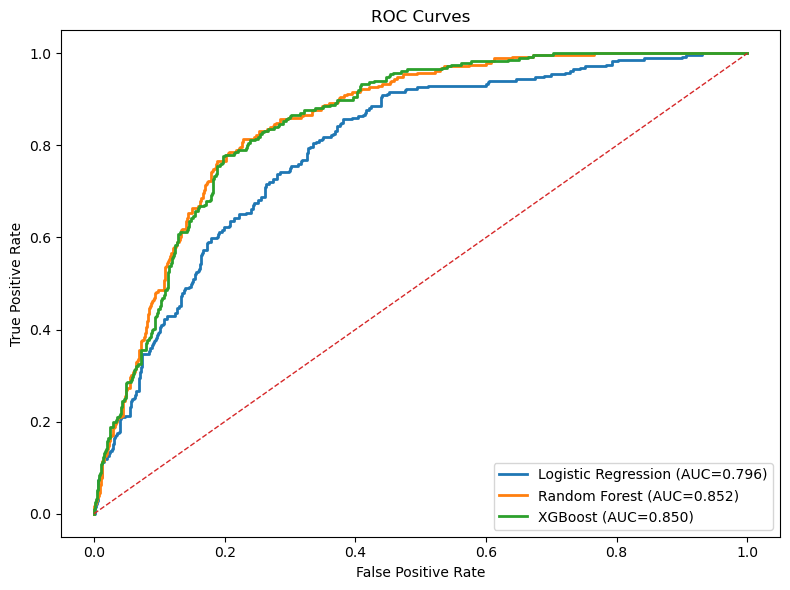

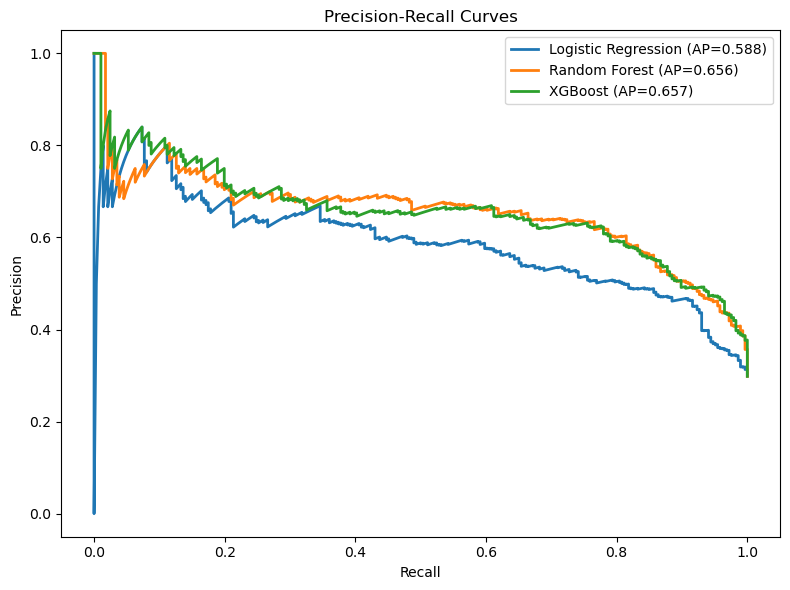

In [22]:
step_09.plot_roc_curves(models, X_test, y_test, save_plot=True)
step_09.plot_precision_recall_curves(models, X_test, y_test, save_plot=True)

In [23]:
logreg_imp = step_09.extract_logreg_importance(
    fitted_pipeline=logreg_best,
    top_n=20,
    save_csv=True,
    relabel=True
)

display(logreg_imp.head(20))

[SUCCESS] Saved Logistic Regression importance table to D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\processed\logreg_feature_importance.csv


,feature,coefficient,abs_coefficient,odds_ratio,feature_label
0,num__PSI_90,-6.351117,6.351117,0.001745,Serious complications composite (PSI-90)
1,num__PSI_03,4.982486,4.982486,145.836514,Pressure ulcer rate
2,num__PSI_11,2.595404,2.595404,13.401996,Postoperative respiratory failure rate
3,num__PSI_13,1.254011,1.254011,3.504372,Postoperative sepsis rate
4,num__PSI_12,1.018628,1.018628,2.769393,Postoperative pulmonary embolism or DVT rate
5,num__OP_18a,0.629984,0.629984,1.877581,"ED time before departure, all patients"
6,num__PSI_10,0.421388,0.421388,1.524075,Postoperative kidney or metabolic complication...
7,num__PSI_06,0.290309,0.290309,1.336840,Iatrogenic pneumothorax rate
8,num__PSI_09,0.236681,0.236681,1.267036,Postoperative hemorrhage or hematoma rate
9,num__PSI_15,0.235190,0.235190,1.265149,Accidental puncture or laceration rate


In [24]:
rf_imp = step_09.extract_tree_importance(
    fitted_pipeline=rf_best,
    model_step_name="rf",
    top_n=20,
    save_csv=True,
    relabel=True
)

xgb_imp = step_09.extract_tree_importance(
    fitted_pipeline=xgb_best,
    model_step_name="xgb",
    top_n=20,
    save_csv=True,
    relabel=True
)

display(rf_imp.head(20))
display(xgb_imp.head(20))

[SUCCESS] Saved rf importance table to D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\processed\rf_feature_importance.csv
[SUCCESS] Saved xgb importance table to D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\processed\xgb_feature_importance.csv


,feature,importance,feature_label
0,num__OP_18a,0.087799,"ED time before departure, all patients"
1,num__PSI_14,0.077148,Postoperative wound dehiscence rate
2,num__PSI_15,0.058578,Accidental puncture or laceration rate
3,num__PSI_10,0.047556,Postoperative kidney or metabolic complication...
4,num__PSI_09,0.044374,Postoperative hemorrhage or hematoma rate
5,num__PSI_13,0.043761,Postoperative sepsis rate
6,num__PSI_12,0.038271,Postoperative pulmonary embolism or DVT rate
7,num__SEP_SH_3HR,0.037181,Septic shock 3-hour bundle performance
8,num__PSI_11,0.036392,Postoperative respiratory failure rate
9,num__PSI_06,0.034430,Iatrogenic pneumothorax rate


,feature,importance,feature_label
0,num__OP_18a,0.138895,"ED time before departure, all patients"
1,num__PSI_14,0.119690,Postoperative wound dehiscence rate
2,num__PSI_15,0.084570,Accidental puncture or laceration rate
3,num__PSI_08,0.042229,Postoperative hip fracture rate
4,num__SEP_SH_3HR,0.039077,Septic shock 3-hour bundle performance
5,num__PSI_13,0.038774,Postoperative sepsis rate
6,num__PSI_09,0.028087,Postoperative hemorrhage or hematoma rate
7,num__PSI_10,0.026784,Postoperative kidney or metabolic complication...
8,num__SEP_1,0.026325,Sepsis and septic shock bundle performance
9,num__PSI_12,0.023873,Postoperative pulmonary embolism or DVT rate


## Permutation Importance

To supplement model-native feature importance, this section computes permutation importance on the held-out test set. This provides a more direct measure of how much predictive performance declines when each feature is disrupted, which can be a more defensible interpretation tool than model-native tree importance alone.

In [25]:
rf_perm_imp = step_09.extract_permutation_importance(
    fitted_pipeline=rf_best,
    X_eval=X_test,
    y_eval=y_test,
    scoring="roc_auc",
    n_repeats=20,
    random_seed=RANDOM_SEED,
    top_n=20,
    save_csv=True,
    csv_name="rf_permutation_importance.csv",
    relabel=True
)

xgb_perm_imp = step_09.extract_permutation_importance(
    fitted_pipeline=xgb_best,
    X_eval=X_test,
    y_eval=y_test,
    scoring="roc_auc",
    n_repeats=20,
    random_seed=RANDOM_SEED,
    top_n=20,
    save_csv=True,
    csv_name="xgb_permutation_importance.csv",
    relabel=True
)

display(rf_perm_imp.head(20))
display(xgb_perm_imp.head(20))

[SUCCESS] Saved permutation importance table to D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\processed\rf_permutation_importance.csv
[SUCCESS] Saved permutation importance table to D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\processed\xgb_permutation_importance.csv


,feature,importance_mean,importance_std,feature_label
0,num__PSI_14,0.013269,0.003417,Postoperative wound dehiscence rate
1,num__OP_18a,0.009983,0.002265,"ED time before departure, all patients"
2,num__PSI_15,0.006527,0.003095,Accidental puncture or laceration rate
3,num__SEP_1,0.006374,0.000910,Sepsis and septic shock bundle performance
4,num__PSI_03,0.005132,0.001453,Pressure ulcer rate
5,num__PSI_13,0.004864,0.001767,Postoperative sepsis rate
6,num__SEP_SH_3HR,0.004257,0.001488,Septic shock 3-hour bundle performance
7,num__SEV_SEP_6HR,0.003398,0.000762,Severe sepsis 6-hour bundle performance
8,num__PSI_08,0.002592,0.001209,Postoperative hip fracture rate
9,num__PSI_10,0.002548,0.002498,Postoperative kidney or metabolic complication...


,feature,importance_mean,importance_std,feature_label
0,num__OP_18a,0.023596,0.003908,"ED time before departure, all patients"
1,num__PSI_14,0.014996,0.004037,Postoperative wound dehiscence rate
2,num__PSI_15,0.011900,0.002891,Accidental puncture or laceration rate
3,num__SEP_1,0.006431,0.001102,Sepsis and septic shock bundle performance
4,num__SEP_SH_3HR,0.003878,0.001907,Septic shock 3-hour bundle performance
5,num__PSI_13,0.003055,0.001050,Postoperative sepsis rate
6,num__PSI_03,0.002086,0.000810,Pressure ulcer rate
7,num__PSI_09,0.001979,0.001909,Postoperative hemorrhage or hematoma rate
8,num__READM_30_PN,0.001836,0.000910,30-day readmission rate for pneumonia patients
9,num__PSI_06,0.001519,0.000536,Iatrogenic pneumothorax rate


[SUCCESS] Saved feature importance plot to D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\reports\figures\logistic_regression_top_features.png


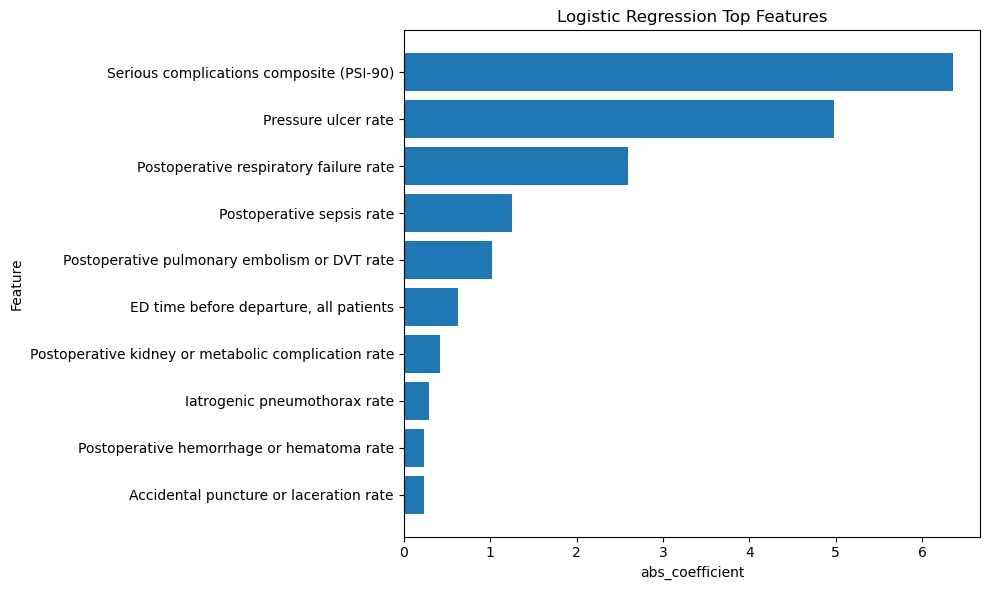

In [26]:
step_09.plot_top_features(
    importance_df=logreg_imp,
    feature_col="feature_label",
    value_col="abs_coefficient",
    title="Logistic Regression Top Features",
    top_n=10,
    save_plot=True
)

plt.show()

[SUCCESS] Saved feature importance plot to D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\reports\figures\random_forest_top_features.png


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Random Forest Top Features'}, xlabel='importance', ylabel='Feature'>)

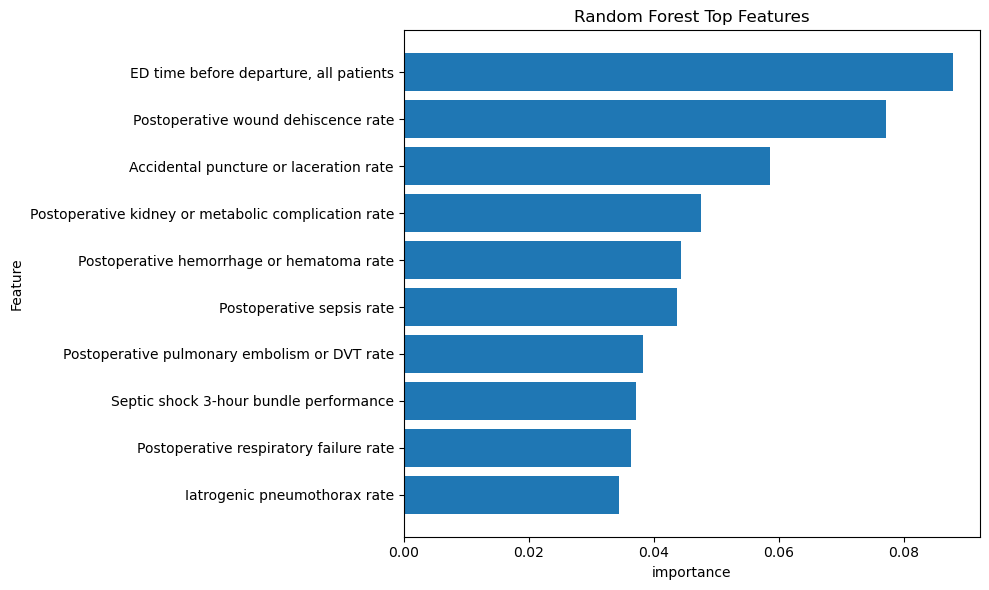

In [27]:
step_09.plot_top_features(
    importance_df=rf_imp,
    feature_col="feature_label",
    value_col="importance",
    title="Random Forest Top Features",
    top_n=10,
    save_plot=True
)

[SUCCESS] Saved feature importance plot to D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\reports\figures\random_forest_permutation_importance.png


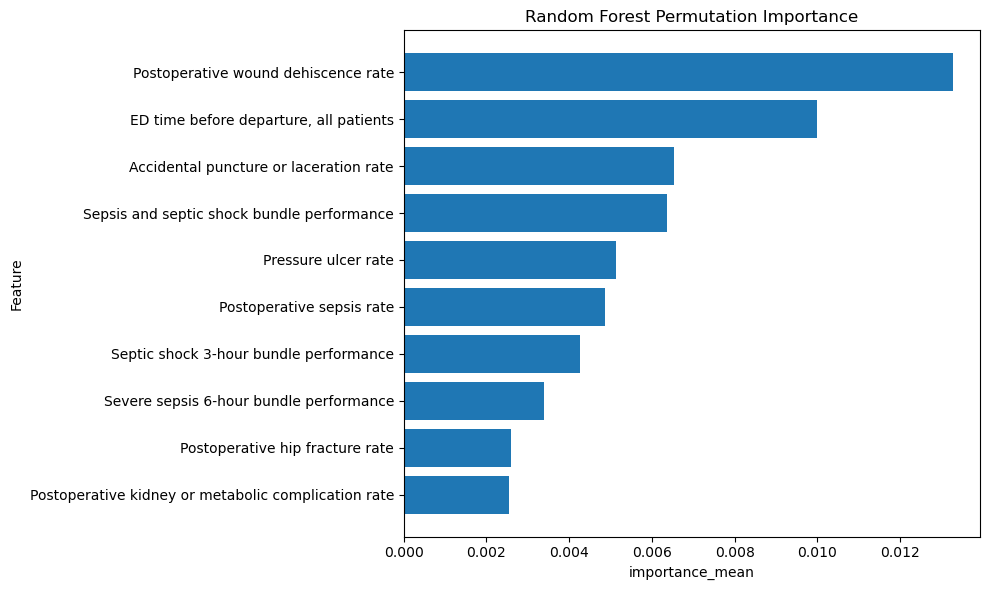

In [28]:
step_09.plot_top_features(
    importance_df=rf_perm_imp,
    feature_col="feature_label",
    value_col="importance_mean",
    title="Random Forest Permutation Importance",
    top_n=10,
    save_plot=True
)

plt.show()

## 10: Model Application to All CMS Facilities

The final project step applies the selected fitted model to the full CMS facility universe rather than only the supervised training cohort.

This creates a facility-level lookup output suitable for Tableau or dashboarding. The output retains key facility identity fields from the CMS Hospital General Information dataset and appends a predicted `HAI_at_risk` classification. Facilities with insufficient feature availability are not forcibly scored and are instead assigned a `"Too little data available"` status.

This final application layer is intended to support a leadership-facing use case, where facilities can be searched and reviewed even if they were not part of the original labeled modeling subset.

Output: all_cms_facility_hai_risk_predictions.csv

In [29]:
# Step 10: Apply final model to all CMS facilities
step_10 = importlib.import_module("10_model_application")
importlib.reload(step_10)

all_facility_predictions = step_10.apply_model_to_all_facilities(
    fitted_model=rf_best,
    df_dict=raw_datasets,
    model_name="Random Forest",
    retained_features_path="../data/processed/retained_model_features.csv",
    feature_manifest_path="../data/processed/feature_manifest.csv",
    min_available_count=5,
    min_available_fraction=0.30,
    threshold=0.40,
    positive_label="Yes",
    negative_label="No",
    insufficient_label="Too little data available",
    save_csv=True,
)

display(all_facility_predictions.head(20))

print("\nPrediction status counts:")
display(
    all_facility_predictions["prediction_status"]
    .value_counts(dropna=False)
    .rename_axis("prediction_status")
    .reset_index(name="facility_count")
)

print("\nPredicted HAI risk label counts:")
display(
    all_facility_predictions["HAI_at_risk_pred_label"]
    .value_counts(dropna=False)
    .rename_axis("HAI_at_risk_pred_label")
    .reset_index(name="facility_count")
)

print("\nRisk tier counts:")
display(
    all_facility_predictions["risk_tier"]
    .value_counts(dropna=False)
    .rename_axis("risk_tier")
    .reset_index(name="facility_count")
)

[APPLICATION FEATURES] Complications_and_Deaths-Hospital: merged 20 feature columns.
[APPLICATION FEATURES] HOSPITAL_QUARTERLY_MSPB_6_DECIMALS: merged 1 feature columns.
[APPLICATION FEATURES] Medicare_Hospital_Spending_Per_Patient-Hospital: merged 1 feature columns.
[APPLICATION FEATURES] Outpatient_Imaging_Efficiency-Hospital: merged 4 feature columns.
[APPLICATION FEATURES] Timely_and_Effective_Care-Hospital: merged 24 feature columns.
[APPLICATION FEATURES] Unplanned_Hospital_Visits-Hospital: merged 14 feature columns.
[SUCCESS] Saved application dataset to: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\processed\all_facility_application_dataset.csv
[SUCCESS] Saved all-facility prediction output to: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-prediction\data\processed\all_cms_facility_hai_risk_predictions.csv
[SUCCESS] Saved prediction status summary to: D:\Documents\School\UVA\MSDS\DS 5003\Project\GitHub\cms-hai-risk-predicti

,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Hospital Type,Hospital Ownership,...,Hospital overall rating,model_used,available_feature_count,available_feature_fraction,prediction_status,HAI_at_risk_pred_binary,HAI_at_risk_pred_label,HAI_at_risk_pred_probability,risk_percentile,risk_tier
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Acute Care Hospitals,Government - Hospital District or Authority,...,4,Random Forest,34,0.9714,Predicted,1,Yes,0.430068,0.492980,Medium
1,010005,MARSHALL MEDICAL CENTERS,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,(256) 593-8310,Acute Care Hospitals,Government - Hospital District or Authority,...,3,Random Forest,35,1.0000,Predicted,1,Yes,0.579900,0.652980,Medium
2,010006,NORTH ALABAMA MEDICAL CENTER,1701 VETERANS DRIVE,FLORENCE,AL,35630,LAUDERDALE,(256) 768-8400,Acute Care Hospitals,Proprietary,...,2,Random Forest,34,0.9714,Predicted,1,Yes,0.644719,0.698808,High
3,010007,MIZELL MEMORIAL HOSPITAL,702 N MAIN ST,OPP,AL,36467,COVINGTON,(334) 493-3541,Acute Care Hospitals,Voluntary non-profit - Private,...,1,Random Forest,30,0.8571,Predicted,0,No,0.331961,0.401589,Medium
4,010008,CRENSHAW COMMUNITY HOSPITAL,101 HOSPITAL CIRCLE,LUVERNE,AL,36049,CRENSHAW,(334) 335-3374,Acute Care Hospitals,Proprietary,...,Not Available,Random Forest,17,0.4857,Predicted,0,No,0.023364,0.023576,Low
5,010011,ST. VINCENT'S EAST,50 MEDICAL PARK EAST DRIVE,BIRMINGHAM,AL,35235,JEFFERSON,(205) 838-3122,Acute Care Hospitals,Voluntary non-profit - Private,...,2,Random Forest,31,0.8857,Predicted,1,Yes,0.738472,0.783311,High
6,010012,DEKALB REGIONAL MEDICAL CENTER,200 MED CENTER DRIVE,FORT PAYNE,AL,35968,DE KALB,(256) 845-3150,Acute Care Hospitals,Proprietary,...,3,Random Forest,35,1.0000,Predicted,1,Yes,0.711912,0.750728,High
7,010016,SHELBY BAPTIST MEDICAL CENTER,1000 FIRST STREET NORTH,ALABASTER,AL,35007,SHELBY,(205) 620-8100,Acute Care Hospitals,Voluntary non-profit - Private,...,2,Random Forest,33,0.9429,Predicted,1,Yes,0.864838,0.988079,High
8,010018,CALLAHAN EYE HOSPITAL,1720 UNIVERSITY BLVD STE 305,BIRMINGHAM,AL,35233,JEFFERSON,(205) 325-8596,Acute Care Hospitals,Voluntary non-profit - Private,...,Not Available,Random Forest,9,0.2571,Too little data available,<NA>,Too little data available,NaN,NaN,Not Scored
9,010019,HELEN KELLER HOSPITAL,1300 SOUTH MONTGOMERY AVENUE,SHEFFIELD,AL,35660,COLBERT,(256) 386-4556,Acute Care Hospitals,Government - Hospital District or Authority,...,2,Random Forest,31,0.8857,Predicted,1,Yes,0.779267,0.845563,High



Prediction status counts:


,prediction_status,facility_count
0,Predicted,3775
1,Too little data available,1651



Predicted HAI risk label counts:


,HAI_at_risk_pred_label,facility_count
0,Yes,2043
1,No,1732
2,Too little data available,1651



Risk tier counts:


,risk_tier,facility_count
0,Not Scored,1651
1,High,1284
2,Medium,1246
3,Low,1245
